<a href="https://colab.research.google.com/github/lamaljalal/MachineLearning/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 300 non-null    object 
 1   Brand                  300 non-null    object 
 2   Manufacture_Year       300 non-null    Int64  
 3   Body_Type              300 non-null    object 
 4   Fuel_Type              300 non-null    object 
 5   Transmission           300 non-null    object 
 6   Engine_CC              300 non-null    int64  
 7   Horsepower             300 non-null    int64  
 8   Mileage_km_per_l       300 non-null    int64  
 9   Price_USD              300 non-null    int64  
 10  Manufacturing_Country  300 non-null    object 
 11  Car_Age                300 non-null    Int64  
 12  Price_Category         300 non-null    object 
 13  HP_per_CC              300 non-null    float64
 14  Age_Category           300 non-null    object 
 15  Effici

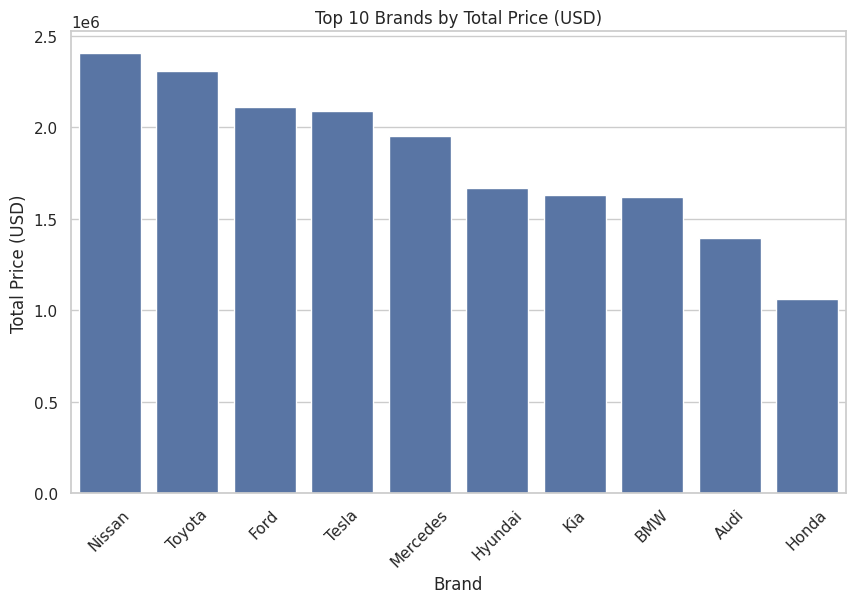

Manufacturing_Country
USA            3368804
Germany        3213260
China          2998026
UK             2996280
South Korea    2893051
Japan          2785226
Name: Price_USD, dtype: int64


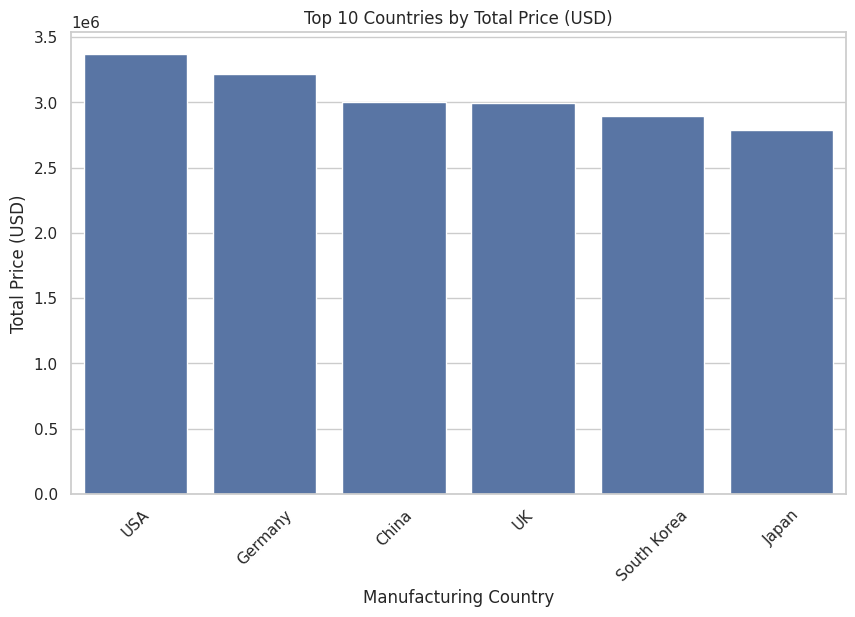

Fuel_Type
Hybrid      5283491
Petrol      4535016
Diesel      4521378
Electric    3914762
Name: Price_USD, dtype: int64


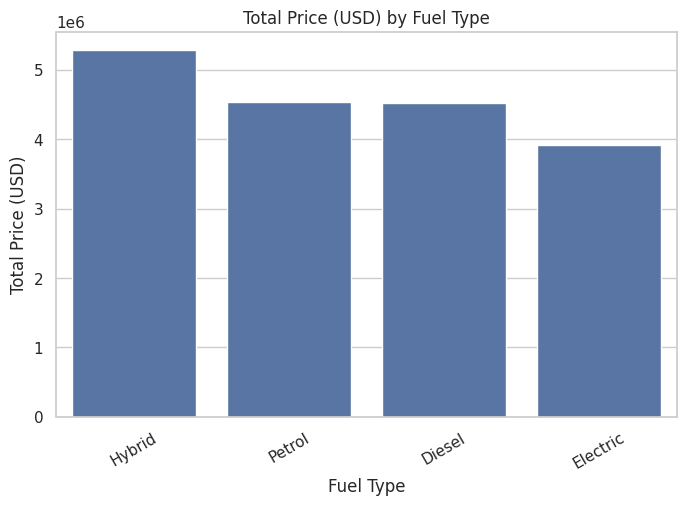

Body_Type
Sedan        4379924
SUV          3712931
Coupe        3528318
Pickup       3396294
Hatchback    3237180
Name: Price_USD, dtype: int64


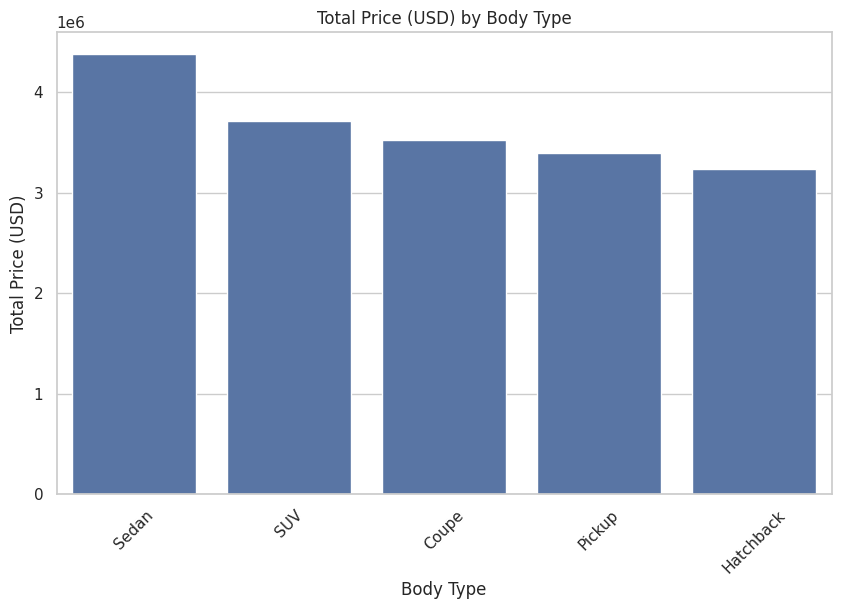

Manufacture_Year
2016     813837
2017     819638
2018     697635
2019     834925
2020    1817291
2021     824614
2022     466952
2023    1314006
2024     508329
2025     712750
Name: Price_USD, dtype: int64


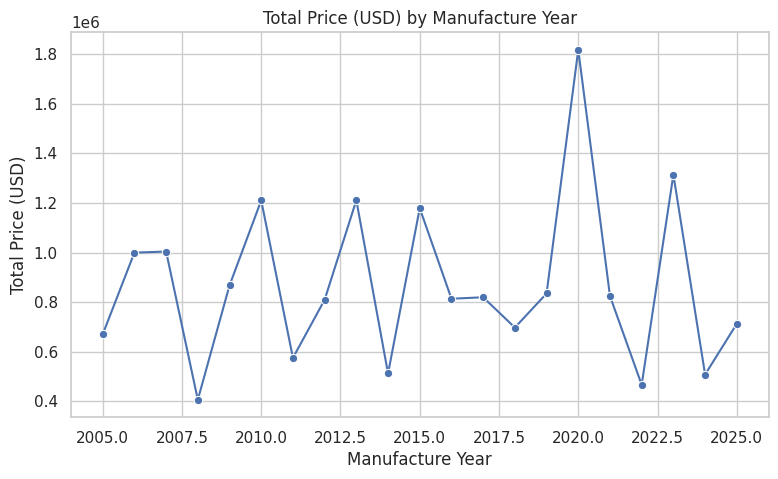

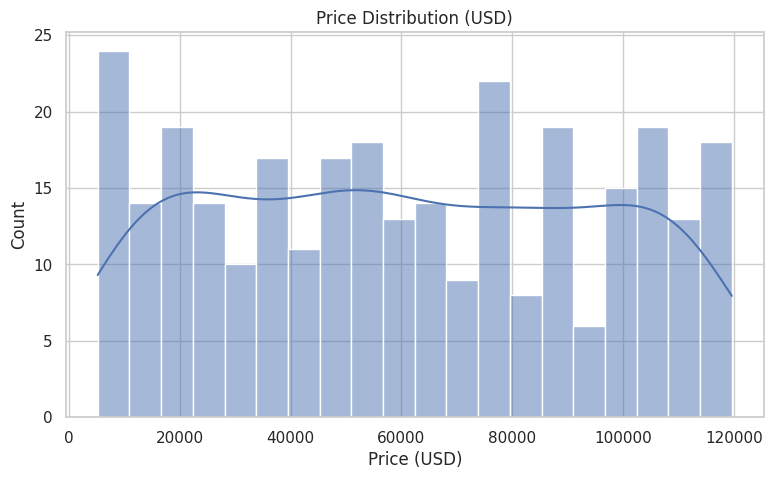

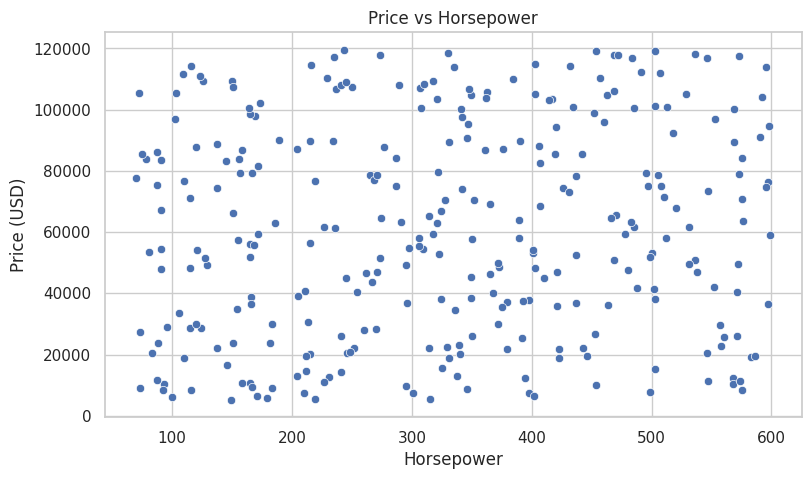

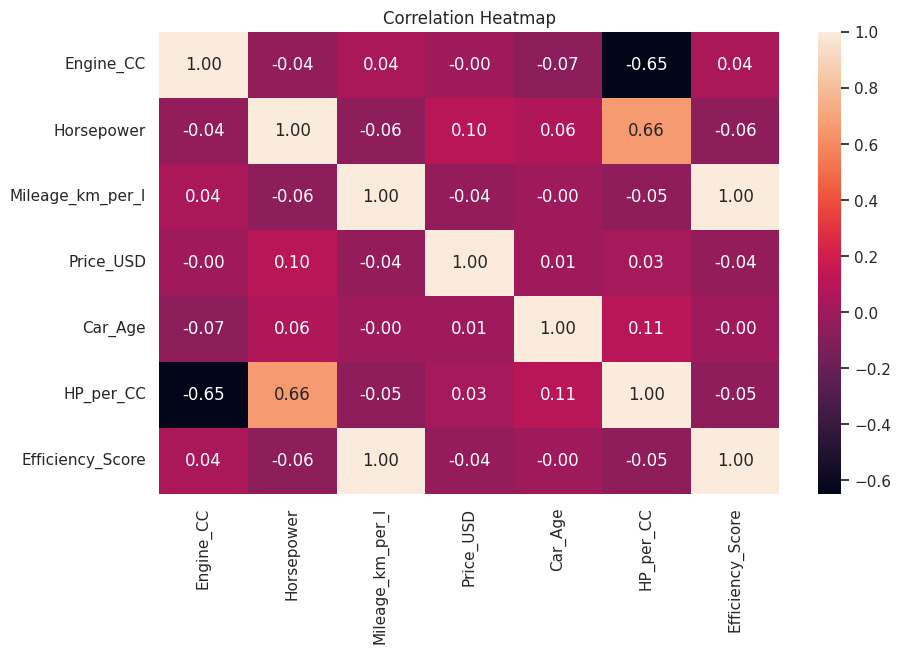

Top Brand (Total Price): Nissan
Top Country (Total Price): USA
Most Common Fuel Type: Petrol
Most Common Body Type: Sedan


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("global_cars_enhanced (1).csv")
df.columns = df.columns.str.strip()

numeric_cols = ["Manufacture_Year", "Engine_CC", "Horsepower", "Mileage_km_per_l", "Price_USD", "Car_Age", "HP_per_CC", "Efficiency_Score"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Manufacture_Year"] = df["Manufacture_Year"].astype("Int64")
df["Car_Age"] = df["Car_Age"].astype("Int64")

df.info()
df.describe(include="all")
df.isna().sum()

df = df.dropna(subset=["Price_USD", "Manufacture_Year"])

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Total Price (USD):", df["Price_USD"].sum())
print("Average Price (USD):", df["Price_USD"].mean())
print("Median Price (USD):", df["Price_USD"].median())

top10_brand = df.groupby("Brand")["Price_USD"].sum().sort_values(ascending=False).head(10)
print(top10_brand)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_brand.index, y=top10_brand.values)
plt.xticks(rotation=45)
plt.title("Top 10 Brands by Total Price (USD)")
plt.xlabel("Brand")
plt.ylabel("Total Price (USD)")
plt.show()

top10_country = df.groupby("Manufacturing_Country")["Price_USD"].sum().sort_values(ascending=False).head(10)
print(top10_country)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_country.index, y=top10_country.values)
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Total Price (USD)")
plt.xlabel("Manufacturing Country")
plt.ylabel("Total Price (USD)")
plt.show()

fuel_sales = df.groupby("Fuel_Type")["Price_USD"].sum().sort_values(ascending=False)
print(fuel_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=fuel_sales.index, y=fuel_sales.values)
plt.xticks(rotation=30)
plt.title("Total Price (USD) by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Total Price (USD)")
plt.show()

body_sales = df.groupby("Body_Type")["Price_USD"].sum().sort_values(ascending=False)
print(body_sales)

plt.figure(figsize=(10,6))
sns.barplot(x=body_sales.index, y=body_sales.values)
plt.xticks(rotation=45)
plt.title("Total Price (USD) by Body Type")
plt.xlabel("Body Type")
plt.ylabel("Total Price (USD)")
plt.show()

year_sales = df.groupby("Manufacture_Year")["Price_USD"].sum().sort_index()
print(year_sales.tail(10))

plt.figure(figsize=(9,5))
sns.lineplot(x=year_sales.index, y=year_sales.values, marker="o")
plt.title("Total Price (USD) by Manufacture Year")
plt.xlabel("Manufacture Year")
plt.ylabel("Total Price (USD)")
plt.show()

plt.figure(figsize=(9,5))
sns.histplot(df["Price_USD"], bins=20, kde=True)
plt.title("Price Distribution (USD)")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(9,5))
sns.scatterplot(x=df["Horsepower"], y=df["Price_USD"])
plt.title("Price vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Price (USD)")
plt.show()

corr_cols = ["Engine_CC", "Horsepower", "Mileage_km_per_l", "Price_USD", "Car_Age", "HP_per_CC", "Efficiency_Score"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("Top Brand (Total Price):", top10_brand.idxmax())
print("Top Country (Total Price):", top10_country.idxmax())
print("Most Common Fuel Type:", df["Fuel_Type"].value_counts().idxmax())
print("Most Common Body Type:", df["Body_Type"].value_counts().idxmax())